## 05 - Model testing and comparing

### 🎯 Notebook's objective

In this notebook, the aim is to test and compare the different models and strategies used. Other models developed in similar studies will also be tested and compared to the models developed in this project. The models were briefly tested in the previous notebook, the tests will now be more complete and comparative.

### 🏛️ Notebook's Structure

The notebook's structure is as follows:

- **Imports**: All necessary libraries and functions will be imported.
- **Model, Scaler, and Data loading**: Each necessary elements will be loaded and imported in this notebook.
- **Predictions**: The models will be used on the test sets to create predicted sets.
- **Evaluation**: Evaluation functions will be defined and used on the predicted results. These will then be visualised and compared with results from other studies.
- **Error analysis**: An error analysis will be performed to try and identify error sources and potential improvement areas.
- **Conclusion**: The notebook will end with a brief conclusion to summarize and discuss the notebook's results.

### 📚 Library and functions imports

A few libraries and functions will be necessary throughout the notebook. 

In [1]:
# Import necessary libraries
import joblib
import torch
import numpy as np
import sys
import matplotlib.pyplot as plt

# Import necessary functions
from sklearn.preprocessing import StandardScaler

# Import functions from model_utils.py
sys.path.append('../models')  
from model_utils import test_model, NeuralNetwork, ESOLDataset, NeuralNetworkDataModule

### 💾 Model, Scaler, and Data loading

The first task is to load the models, scaler, and data into this notebook.

In [2]:
# Load the trained regression models and scalers using joblib 
rf_model = joblib.load("../models/RandomForest.pth")
xgb_model = joblib.load("../models/XGBoost.pth")
x_scaler = joblib.load("../models/feature_scaler.pth")

# Import the data
x_train = np.load("../data/final/X_train.npy")
y_train = np.load("../data/final/y_train.npy")
x_test  = np.load("../data/final/X_test.npy")
y_test  = np.load("../data/final/y_test.npy")

# Standardize the features (delete later if this is done in a different notebook)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Convert percentage yield values from 0-100 into a 0-1 range (delete later if this is done in a different notebook)
y_train = y_train / 100.0
y_test = y_test / 100.0

# Load the trained neural network model using PyTorch's state_dict
input_size = x_train.shape[1]
hidden_size = 128
model = NeuralNetwork.load_from_checkpoint("../models/lightning_nn.ckpt", input_sz=input_size, hidden_sz=hidden_size, lr=1e-3)
model.eval()

NeuralNetwork(
  (net): Sequential(
    (0): Linear(in_features=474, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): ReLU()
    (10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=1, bias=True)
  )
)

### 🔮 Predictions

Let's now use the models to obtain their respective predicted results.

In [3]:
# Use the regression models on the test set
y_pred_rf = rf_model.predict(x_test_scaled)
y_pred_xgb = xgb_model.predict(x_test_scaled)

# Use the neural network model on the test set
y_pred_nn = model(torch.tensor(x_test_scaled, dtype=torch.float32)).squeeze().detach().numpy()

### 📝 Evaluation

Now the predicted results must be compared to the real values to evaluate the performance of different models. First a few evaluation functions must be defined. The testing functions defined in the previous notebook can be reused to simplify this task.

#### **Evaluation functions definition**

In [4]:
# Parity plot function for ml models
def parity_plot(y_true, y_pred, model_name, title):
    # Use the test_model function to calculate metrics
    metrics = test_model(model_name, y_true, y_pred)

    # Create a parity plot
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([0, 1], [0, 1], 'r--')  # Line for perfect predictions
    plt.xlabel('Actual Yield')
    plt.ylabel('Predicted Yield')
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid()

    # Display metrics in the corner of the plot
    metrics_text = (
        f"RMSE: {metrics['RMSE']:.4f}\n"
        f"MAE: {metrics['MAE']:.4f}\n"
        f"R2: {metrics['R2 Score']:.4f}\n"
        f"Explained Var: {metrics['Explained Variance Score']:.4f}"
    )
    plt.text(
        0.05,
        0.95,
        metrics_text,
        transform=plt.gca().transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='black', boxstyle='round,pad=0.5')
    )

    plt.show()

# Error distribution visualization - Histogram
def plot_error_histogram(y_true, y_pred, model_name, title=None, bins=30, absolute=False):
    """
    Plot histogram of prediction errors.
    
    Parameters:
    y_true: True labels
    y_pred: Predicted labels
    model_name: Name of the model for labeling
    title: Optional title for the plot
    bins: Number of histogram bins
    absolute: If True, plot absolute errors; if False, plot signed errors (residuals)
    """
    errors = y_pred - y_true
    if absolute:
        errors = np.abs(errors)
    
    plt.figure(figsize=(10, 5))
    plt.hist(errors, bins=bins, alpha=0.7, edgecolor='black', color='steelblue')
    plt.xlabel('Error (Absolute)' if absolute else 'Error (Residuals)')
    plt.ylabel('Frequency')
    plt.title(title or f'{model_name} - Error Distribution')
    plt.axvline(np.mean(errors), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(errors):.4f}')
    plt.axvline(np.median(errors), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(errors):.4f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
# Error distribution visualization - Boxplot with statistics
def plot_error_boxplot(y_true, y_pred, model_name, title=None, absolute=False):
    """
    Plot boxplot of prediction errors with statistical summary.
    
    Parameters:
    y_true: True labels
    y_pred: Predicted labels
    model_name: Name of the model for labeling
    title: Optional title for the plot
    absolute: If True, plot absolute errors; if False, plot signed errors (residuals)
    """
    errors = y_pred - y_true
    if absolute:
        errors = np.abs(errors)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    bp = ax.boxplot(errors, vert=True, patch_artist=True, widths=0.5)
    
    # Customize boxplot colors
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    for whisker in bp['whiskers']:
        whisker.set(color='black', linewidth=1.5)
    for cap in bp['caps']:
        cap.set(color='black', linewidth=1.5)
    for median in bp['medians']:
        median.set(color='red', linewidth=2)
    
    ax.set_ylabel('Error (Absolute)' if absolute else 'Error (Residuals)')
    ax.set_title(title or f'{model_name} - Error Distribution')
    ax.set_xticklabels([model_name])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add statistics as text
    stats_text = (
        f"Mean: {np.mean(errors):.4f}\n"
        f"Median: {np.median(errors):.4f}\n"
        f"Std Dev: {np.std(errors):.4f}\n"
        f"Min: {np.min(errors):.4f}\n"
        f"Max: {np.max(errors):.4f}"
    )
    ax.text(1.15, np.max(errors) * 0.8, stats_text, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

# Metrics comparison bar plot function
def plot_metrics_comparison(metrics_list, title_prefix="Model Comparison"):
    """
    Plot comparison of all metrics across multiple models using bar plots.
    
    Parameters:
    metrics_list: List of dictionaries returned by test_model() for different models
    title_prefix: Prefix for the main plot title
    """
    # Extract model names and metrics
    model_names = [m['Model'] for m in metrics_list]
    rmse_values = [m['RMSE'] for m in metrics_list]
    mae_values = [m['MAE'] for m in metrics_list]
    r2_values = [m['R2 Score'] for m in metrics_list]
    var_values = [m['Explained Variance Score'] for m in metrics_list]
    
    # Create subplots for each metric
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title_prefix, fontsize=16, fontweight='bold')
    
    # Plot 1: RMSE (lower is better)
    axes[0, 0].bar(model_names, rmse_values, color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[0, 0].set_ylabel('RMSE', fontsize=11, fontweight='bold')
    axes[0, 0].set_title('Root Mean Squared Error (Lower is Better)')
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(rmse_values):
        axes[0, 0].text(i, v + max(rmse_values)*0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Plot 2: MAE (lower is better)
    axes[0, 1].bar(model_names, mae_values, color='darkorange', alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[0, 1].set_ylabel('MAE', fontsize=11, fontweight='bold')
    axes[0, 1].set_title('Mean Absolute Error (Lower is Better)')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(mae_values):
        axes[0, 1].text(i, v + max(mae_values)*0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Plot 3: R2 Score (higher is better)
    axes[1, 0].bar(model_names, r2_values, color='green', alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[1, 0].set_ylabel('R² Score', fontsize=11, fontweight='bold')
    axes[1, 0].set_title('R² Score (Higher is Better)')
    axes[1, 0].set_ylim([0, 1.05])
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(r2_values):
        axes[1, 0].text(i, v + 0.03, f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Plot 4: Explained Variance Score (higher is better)
    axes[1, 1].bar(model_names, var_values, color='purple', alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[1, 1].set_ylabel('Explained Variance Score', fontsize=11, fontweight='bold')
    axes[1, 1].set_title('Explained Variance Score (Higher is Better)')
    axes[1, 1].set_ylim([0, 1.05])
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(var_values):
        axes[1, 1].text(i, v + 0.03, f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

#### **ML Models Evaluation**

Now the functions can be used on the predicted results.

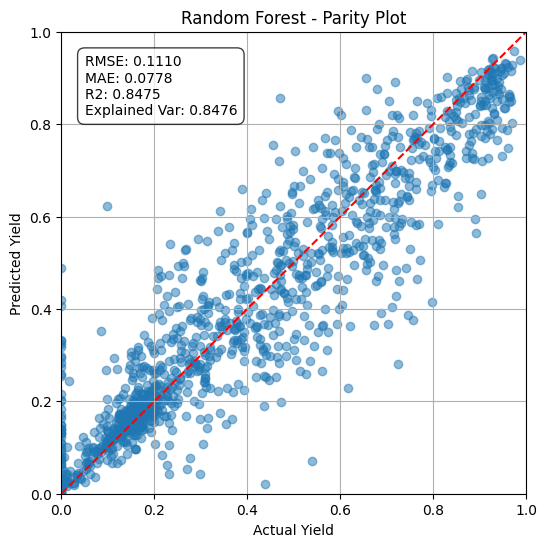

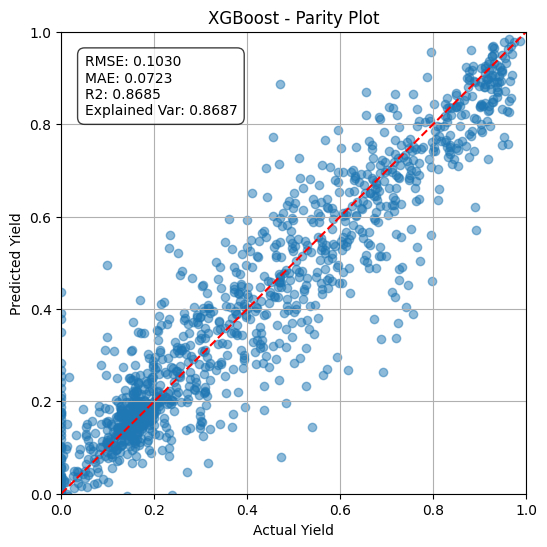

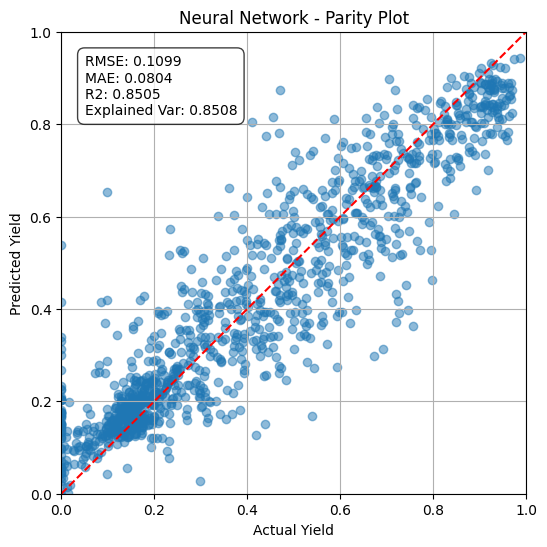

In [5]:
# Parity plots for all models
parity_plot(y_test, y_pred_rf, "Random Forest", "Random Forest - Parity Plot")
parity_plot(y_test, y_pred_xgb, "XGBoost", "XGBoost - Parity Plot")
parity_plot(y_test, y_pred_nn, "Neural Network", "Neural Network - Parity Plot")

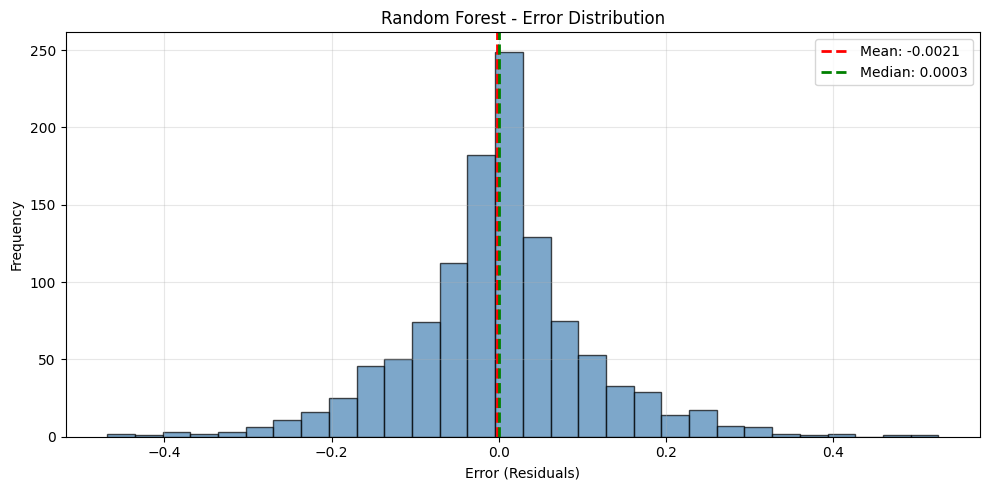

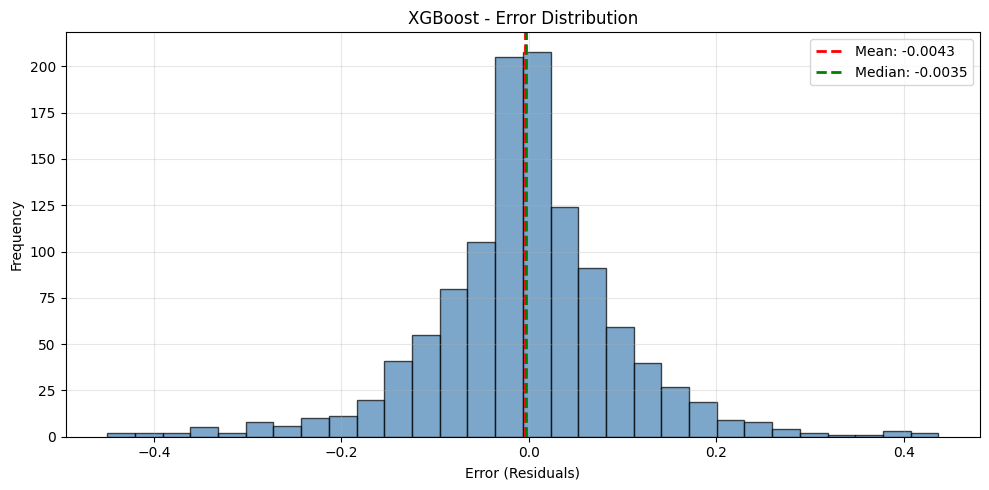

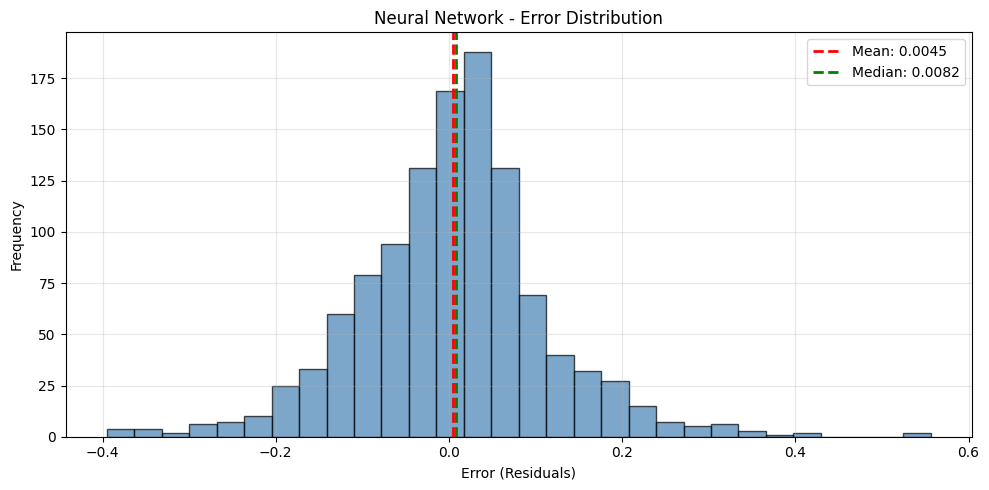

In [6]:
# Error distribution visualizations for all models - Histograms
plot_error_histogram(y_test, y_pred_rf, "Random Forest", "Random Forest - Error Distribution")
plot_error_histogram(y_test, y_pred_xgb, "XGBoost", "XGBoost - Error Distribution")
plot_error_histogram(y_test, y_pred_nn, "Neural Network", "Neural Network - Error Distribution")

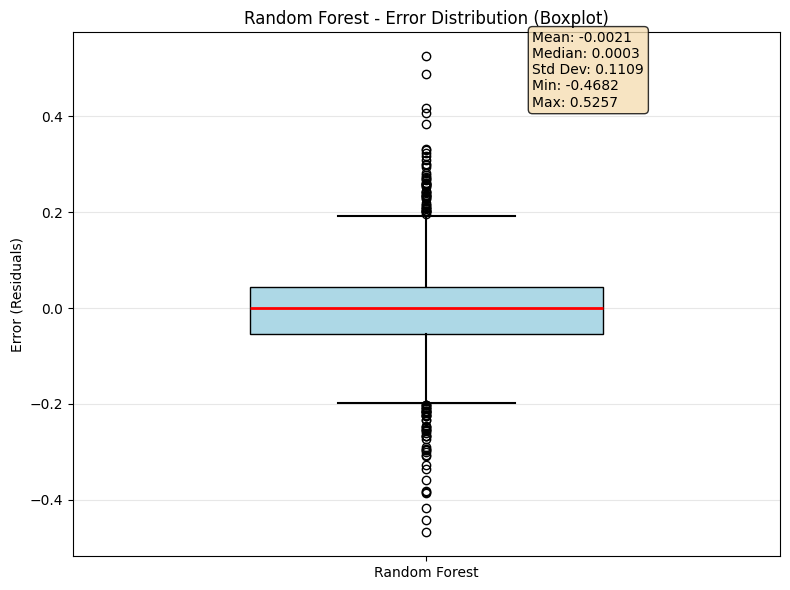

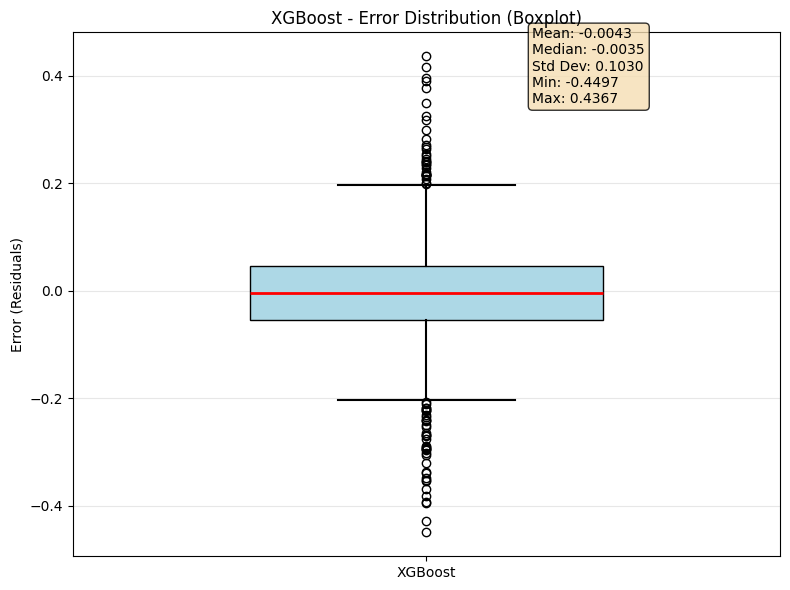

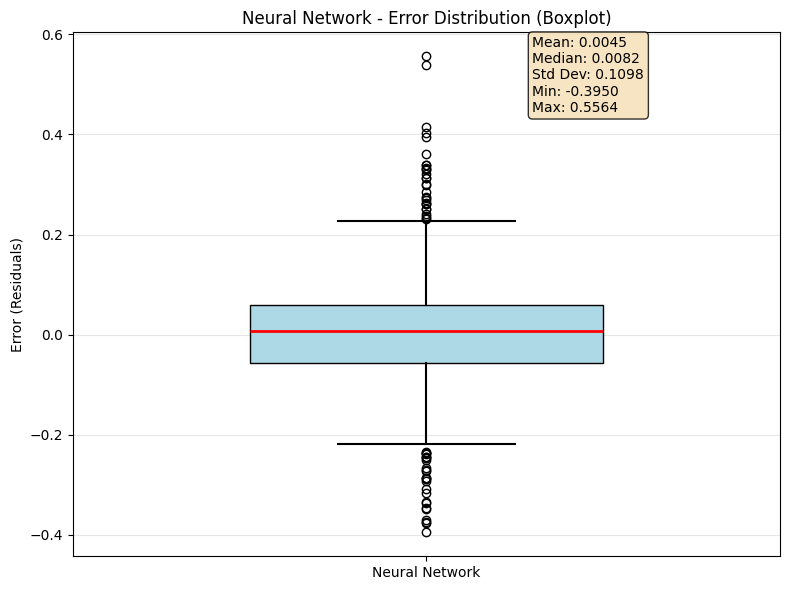

In [7]:
# Error distribution visualizations for all models - Boxplots with statistics
plot_error_boxplot(y_test, y_pred_rf, "Random Forest", "Random Forest - Error Distribution (Boxplot)")
plot_error_boxplot(y_test, y_pred_xgb, "XGBoost", "XGBoost - Error Distribution (Boxplot)")
plot_error_boxplot(y_test, y_pred_nn, "Neural Network", "Neural Network - Error Distribution (Boxplot)")

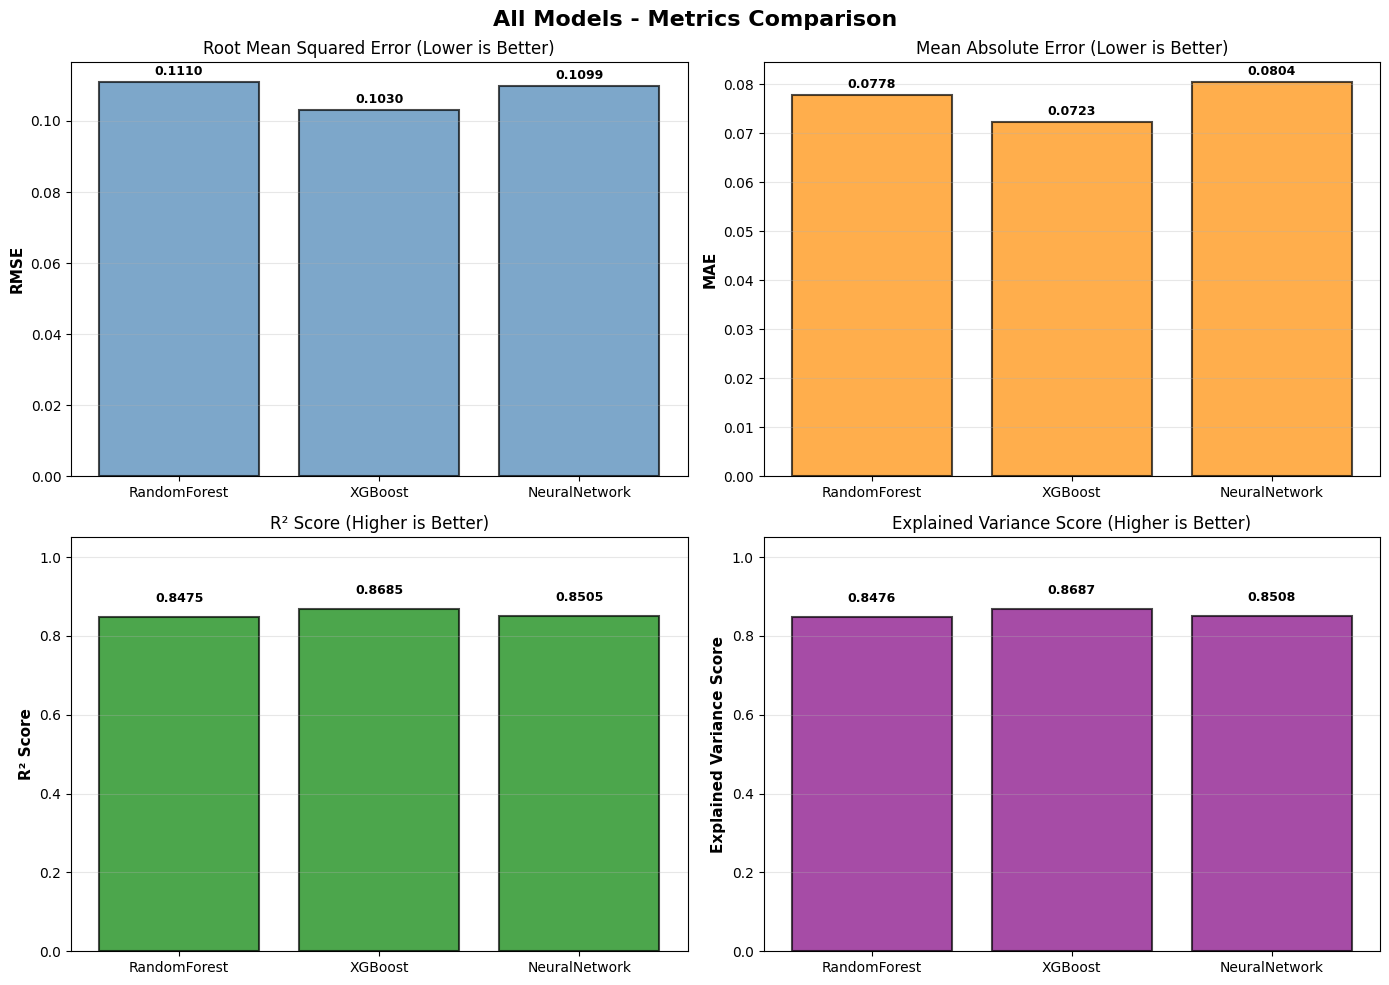

In [8]:
# Metrics comparison bar plot
# Collect metrics from all models
metrics_rf = test_model("RandomForest", y_test, y_pred_rf)
metrics_xgb = test_model("XGBoost", y_test, y_pred_xgb)
metrics_nn = test_model("NeuralNetwork", y_test, y_pred_nn)

# Create comparison plot
plot_metrics_comparison([metrics_rf, metrics_xgb, metrics_nn], "All Models - Metrics Comparison")